In [91]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [122]:
df = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')

In [123]:
df.shape

(42000, 785)

In [124]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
7627,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [125]:
import matplotlib.pyplot as plt

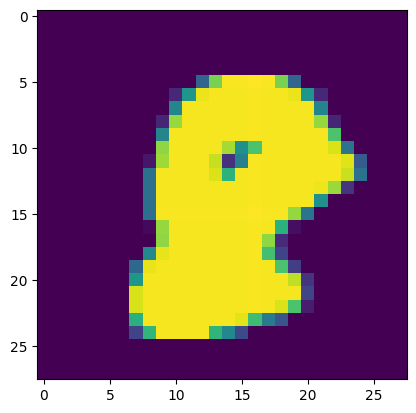

In [126]:
plt.imshow(df.iloc[18221,1:].values.reshape(28,28))

In [127]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [129]:
X_train.shape

(33600, 784)

In [130]:
from sklearn.neighbors import KNeighborsClassifier

In [131]:
knn = KNeighborsClassifier()

In [132]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [133]:
import time
start = time.time()
y_pred = knn.predict(X_test)
print(time.time() - start)

11.993195056915283


In [134]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9648809523809524

In [135]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [138]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [139]:
# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=150)


In [140]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [141]:
X_train_trf.shape

(33600, 150)

In [142]:
knn = KNeighborsClassifier()

In [143]:
knn.fit(X_train_trf,y_train)

KNeighborsClassifier()

In [144]:
y_pred = knn.predict(X_test_trf)

In [145]:
accuracy_score(y_test,y_pred)

0.9521428571428572

In [156]:
# Tarnsforming to a 2D co-ordindate system
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)


In [157]:
X_train_trf

array([[-2.71858116, -0.48958749],
       [-0.67708058, -6.75390419],
       [-3.03330317,  6.5095874 ],
       ...,
       [ 2.14880431,  0.78051178],
       [ 1.05965204,  0.94791507],
       [17.70257908,  1.96174223]])

In [162]:
import plotly.express as px
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()


In [163]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

In [164]:
# Transforming In 3D
pca = PCA(n_components = 3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [165]:
X_train_trf

array([[-2.71862612, -0.4897918 ,  1.13557852],
       [-0.67694672, -6.75446561, -2.3354057 ],
       [-3.03323082,  6.51017127,  7.49185208],
       ...,
       [ 2.14882815,  0.78098691, -0.74758275],
       [ 1.05955123,  0.94803082,  3.94951058],
       [17.70256987,  1.96179887, -4.94367571]])

In [166]:
import plotly.express as px
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
              color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20),
    paper_bgcolor="LightSteelBlue",
)
fig.show()

In [167]:
# EigenValues
pca.explained_variance_

array([40.67111198, 29.17023391, 26.74459615])

In [170]:
# EigenVectors
pca.components_

array([[ 4.20171427e-17,  6.61828700e-18,  4.29142840e-20, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 4.63483126e-17,  2.98696874e-17, -3.21885782e-19, ...,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00],
       [ 5.13897054e-18,  2.19035280e-18, -5.79845774e-19, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [171]:
# EigenVectors
pca.components_.shape

(3, 784)

In [172]:
pca.explained_variance_ratio_

array([0.05785192, 0.0414927 , 0.03804239])

In [173]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [174]:
pca.explained_variance_.shape


(784,)

In [175]:
pca.components_.shape

(784, 784)

In [176]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

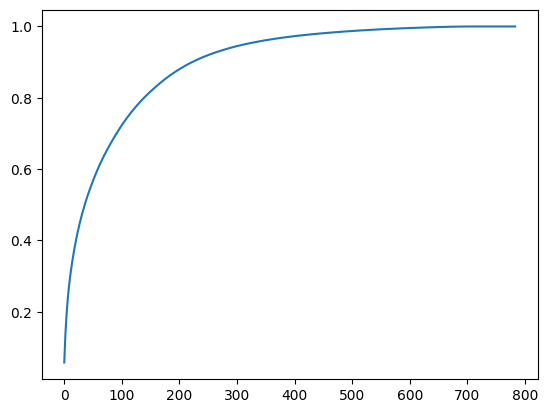

In [177]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))